# Efficiency and Fairness per model

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Classes.bar import Bar
from Config.config import PATHS

In [2]:
def plot_stability(list_of_alternations, list_of_titles, num_rounds):
	fig, axes = plt.subplots(len(list_of_alternations))
	for i, alternations in enumerate(list_of_alternations):
		# Detect number of agents
		num_agents = len(alternations[0])
		# Create bar object
		bar = Bar(
			num_agents=num_agents,
			threshold=0.5
		)
		bar.history = alternations * (num_rounds // len(alternations)) + alternations[:num_rounds % len(alternations)]
		attendance_file_name = None #'alternations.png'
		bar.render(
			ax=axes[i],
			file=attendance_file_name,
			num_rounds=len(bar.history)
		)
#		axes[i].imshow(plt.imread(attendance_file_name))
		if list_of_titles is not None:
			axes[i].set_title(list_of_titles[i])
		axes[i].axis('off')
	return fig


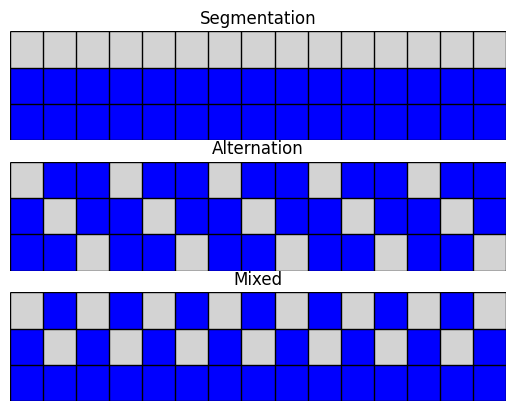

In [3]:
num_rounds = 15
list_of_alternations = [
	# [np.random.randint(0, 2, 3).tolist() for _ in range(num_rounds)],
	[[1, 1, 0]],
	[[1, 1, 0], [1, 0, 1], [0, 1, 1]],
	[[1, 1, 0], [1, 0, 1]],
]
fig = plot_stability(
    list_of_alternations=list_of_alternations, 
    list_of_titles = ['Segmentation', 'Alternation', 'Mixed'],
    num_rounds=num_rounds
)
fig.savefig(PATHS['exploratory_figures'] / 'Coordination_types.png', dpi=300)

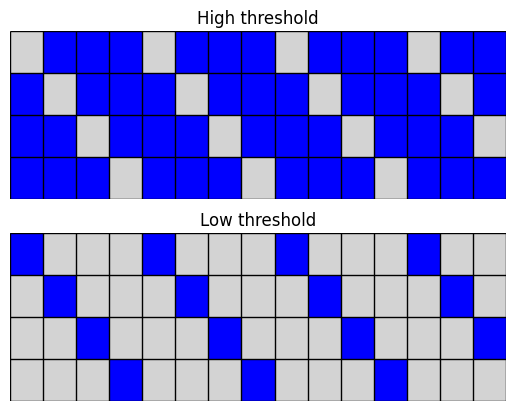

In [6]:
num_rounds = 15
list_of_alternations = [
	[[1, 1, 1, 0], [1, 1, 0, 1], [1, 0, 1, 1], [0, 1, 1, 1]],
	[[0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0], [1, 0, 0, 0]],
]
fig = plot_stability(
    list_of_alternations=list_of_alternations, 
    list_of_titles = ['High threshold', 'Low threshold'],
    num_rounds=num_rounds
)
fig.savefig(PATHS['exploratory_figures'] / 'Symmetry_of_coordination.png', dpi=300)

/var/folders/2l/9hd8041n255250thyc7mhkq80000gn/T/ipykernel_68255/1011705264.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


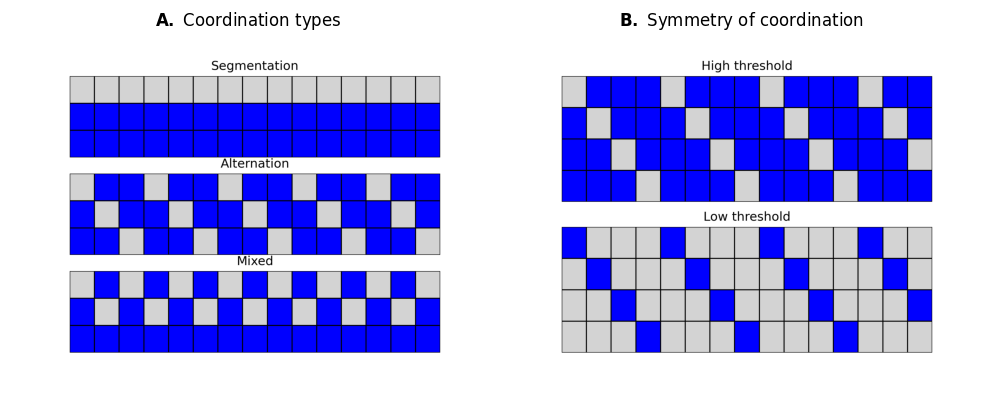

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(plt.imread(PATHS['exploratory_figures'] / 'Coordination_types.png'))
axes[0].set_title(r'$\bf{A.}$ Coordination types')
axes[1].imshow(plt.imread(PATHS['exploratory_figures'] / 'Symmetry_of_coordination.png'))
axes[1].set_title(r'$\bf{B.}$ Symmetry of coordination')
for ax in axes:
    ax.axis('off')
fig.tight_layout()
fig.savefig(PATHS['exploratory_figures'] / 'Fig1.png', dpi=300)
fig.show()

In [ ]:
from Classes.bar import Bar
from Classes.cognitive_model_agents import AttendanceM3

free_paramters = {
    'inverse_temperature': 32,
    'bias': 0.4,
    'learning_rate':0.1,
    'len_history':2,
    'delta':1
}
fixed_parameters = {
    'num_agents':4,
    'threshold':0.75
}

In [ ]:
bar = Bar(**fixed_parameters)
agent = AttendanceM3(
    free_parameters=free_paramters,
    fixed_parameters=fixed_parameters,
    n=fixed_parameters['num_agents'] - 1
)
payoffs = []
attendances = []
probability_go = []
probability_no_go = []
actions = [
# High threshold
    [1, 0, 1, 0, 1, 1, 0, 1, 0],
    [1, 1, 1, 0, 1, 1, 0, 1, 0],
    [1, 1, 1, 0, 1, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 1, 0, 1],
]
actions = np.array(actions).T.tolist()
num_rounds = 7

In [ ]:
for i in range(num_rounds):
    if i < len(actions):
        decisions = actions[i]
    # Update bar with decisions
    attendance, scores = bar.step(decisions)
    # Find payoff
    payoff = agent.payoff(decisions[0], decisions)
    payoffs.append(payoff)
    # Find attendances
    average_go = np.mean(agent.decisions + [decisions[0]])
    attendances.append(average_go)
    # Update agents with decisions
    agent.update(scores[0], decisions)
    print(f"Decisions: {decisions}, Payoff: {payoff}")
    # Find preference not going
    prob_go = agent.go_probability()
    probability_no_go.append(1 - prob_go)
    probability_go.append(prob_go)

Decisions: [1, 1, 1, 0], Payoff: 1
Decisions: [0, 1, 1, 1], Payoff: 0
Decisions: [1, 1, 1, 1], Payoff: -1
Decisions: [0, 0, 0, 1], Payoff: 0
Decisions: [1, 1, 1, 0], Payoff: 1
Decisions: [1, 1, 1, 1], Payoff: -1
Decisions: [0, 0, 0, 1], Payoff: 0


Text(-0.1, 0.235, 'Pl2')

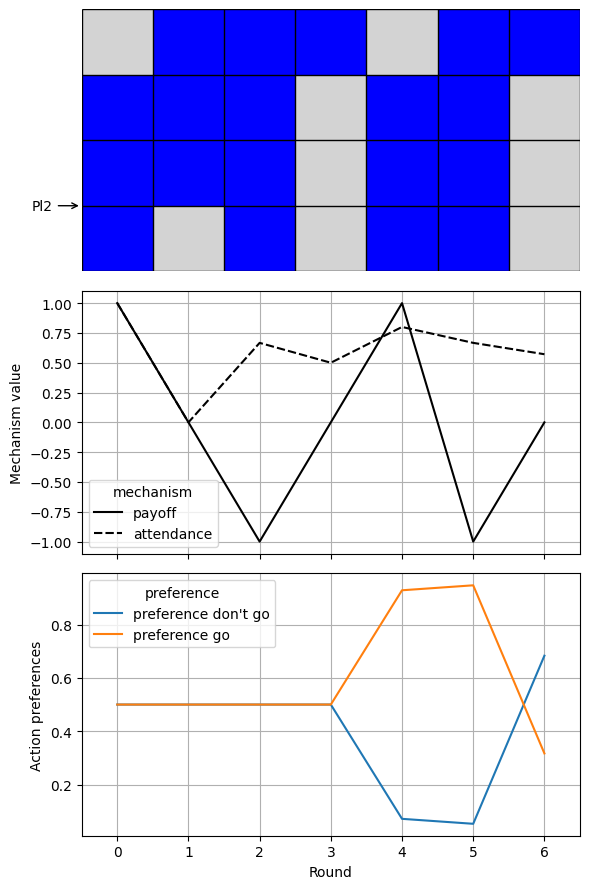

In [ ]:
fig, ax = plt.subplots(
    3, 1, 
    figsize=(6,9), 
    tight_layout=True,
)

bar.render(ax=ax[0], num_rounds=num_rounds)

n1, n2 = len(payoffs), len(attendances)
df_values = pd.DataFrame({
    'round': list(range(n1)) + list(range(n2)),
    'value': payoffs + attendances,
    'mechanism': ["payoff"]*n1  + ["attendance"]*n2
})

n1, n2 = len(probability_no_go), len(probability_go)
df_preferences = pd.DataFrame({
    'round': list(range(n1)) + list(range(n2)),
    'value': probability_no_go + probability_go,
    'preference': ["preference don't go"]*n1 + ["preference go"]*n2
})


sns.lineplot(
    x="round", y="value", style="mechanism",
    style_order=["payoff", "attendance"],
    data=df_values, ax=ax[1],
    color='black'
)
ax[1].grid()
ax[1].set_ylabel('Mechanism value')
ax[1].set_xlim([-0.5, num_rounds - 0.5])
ax[1].set_xlabel('')
ax[1].set_xticks(range(num_rounds)) 
ax[1].set_xticklabels([])

sns.lineplot(
    x="round", y="value", hue="preference",
    hue_order=["preference don't go", "preference go"],
    data=df_preferences, ax=ax[2],
    color='black'
)
ax[2].set_ylabel('Action preferences')

ax[2].set_xlabel('Round')
ax[2].set_xlim([-0.5, num_rounds - 0.5])
ax[2].set_xticks(range(num_rounds)) 
ax[2].set_xticklabels(range(num_rounds))
ax[2].grid()

ax[0].annotate(
    'Pl2',
    xy=(0, 0.25), xycoords='axes fraction',
    xytext=(-0.1, 0.235), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='->'),
)

In [ ]:
import sys
sys.path.append('../src')

import re
import ast
import pandas as pd

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.interaction import Performer
from Utils.indices import AlternationIndex
from Classes.cognitive_model_agents import *

In [ ]:
path_to_data = PATHS['simulated_data'] / 'optimal_parameters.csv'
optimal_parameters = pd.read_csv(path_to_data)

In [ ]:
def parse_params(s):
    if not isinstance(s, str):
        return s
    # Replace np.float64(x) and np.int64(x) with x
    s = re.sub(r'np\.float64\(([^)]+)\)', r'\1', s)
    s = re.sub(r'np\.int64\(([^)]+)\)', r'\1', s)
    return ast.literal_eval(s)

In [ ]:
MODEL_BY_NAME = {m.name(): m for m in MODELS}

fixed_parameters = {
    'num_agents': 2,
    'threshold': 0.5,
}
simulation_parameters = {
    'num_rounds': 10,
    'num_episodes': 10,
    'verbose': False
}

df_list =[] 
for idx, row in optimal_parameters.iterrows():
    if row['model'].startswith('Priors'):
        continue
    model_class = MODEL_BY_NAME[row['model']]
    free_parameters = parse_params(row['params'])
    df = Performer.sim(
        agent_class=model_class,
        fixed_parameters=fixed_parameters,
        free_parameters=free_parameters,
        simulation_parameters=simulation_parameters
    )
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
df.head(2)


,id_sim,round,attendance,id_player,decision,score,model,threshold,num_agents
0,1b8f33a6-232e-11f1-a48a-b5d0ad9dae1a,0,"[1, 0]",0,1,1,,0.5,2
1,1b8f33a6-232e-11f1-a48a-b5d0ad9dae1a,0,"[1, 0]",1,0,0,,0.5,2


In [ ]:
gm = GetMeasurements(
    data=df, 
    measures=[
        'efficiency', 'inequality',
        'bounded_efficiency', 
        'entropy', 'conditional_entropy', 
        'conditional_entropy_2nd_order', 'min_entropy'
    ],
    normalize=True,
)
data = gm.get_measurements()
index_gen = AlternationIndex.from_file(priority='mlp')
data['inequality'] = index_gen(data)
data.head(2)

Exception: Error: No column data found. Should be one of "id_sim", "room", or "group".
Columns found: Index(['round', 'attendance', 'id_player', 'decision', 'score'], dtype='str')